# 8. Model Monitoring — Is the Model Still Working?

Once a prediction model goes live, its accuracy can **silently degrade** as real-world
booking patterns change. This notebook answers a critical operational question:
*is the deployed model still behaving as expected on new bookings?*

**How we test this**: We compare the model's behaviour on three consecutive months of
bookings — June (our baseline), July, and August — to see whether predictions shift
over time.

**What to look for**:
- **Score drift** — Are the model's predicted probabilities changing?
- **Feature drift** — Are the characteristics of incoming bookings changing?
- **Calibration drift** — When the model says "60% chance of cancellation", is it still right ~60% of the time?
- **Business metric drift** — Are cancellation rates, room prices, or revenue at risk shifting?

**Prerequisites**: `make train && make benchmark` — all inputs come from
`reports/test_predictions_for_powerbi.csv` (pre-computed; no retraining here).

> In a live deployment, replace the *batch* DataFrames with real inference logs
> from your prediction database or feature store.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

from src.eval.notebook_utils import project_root, save_thesis_figure, setup_plotting

cfg    = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT   = project_root()

# ── Load test predictions (baseline + simulated production batches) ───────────
df = pd.read_csv(ROOT / "reports" / "test_predictions_for_powerbi.csv")

# Split by arrival month — June = baseline, July/August = production batches
MONTH_ORDER = ["June", "July", "August"]
baseline = df[df["arrival_date_month"] == "June"].copy()
batch1   = df[df["arrival_date_month"] == "July"].copy()
batch2   = df[df["arrival_date_month"] == "August"].copy()

BATCHES = {"Baseline (June)": baseline, "Batch 1 (July)": batch1, "Batch 2 (Aug)": batch2}
COLORS  = {"Baseline (June)": "#4e79a7", "Batch 1 (July)": "#f28e2b", "Batch 2 (Aug)": "#e15759"}

print(f"Baseline  (June):   {len(baseline):>5,} rows | cancel rate {baseline['is_canceled'].mean():.1%}")
print(f"Batch 1   (July):   {len(batch1):>5,} rows | cancel rate {batch1['is_canceled'].mean():.1%}")
print(f"Batch 2   (August): {len(batch2):>5,} rows | cancel rate {batch2['is_canceled'].mean():.1%}")

Baseline  (June):   1,689 rows | cancel rate 41.9%
Batch 1   (July):   5,310 rows | cancel rate 37.4%
Batch 2   (August): 4,923 rows | cancel rate 36.8%


---
## 8.1 What Kinds of Problems Can Appear After Deployment?

Three categories of change can silently degrade model performance:

| Category | Plain-English meaning | How we measure it | When to worry |
|----------|----------------------|-------------------|---------------|
| **Score drift** | The model's predictions start looking different from what we saw at launch | PSI (a number measuring how much the distribution shifted) | PSI > 0.10 investigate, > 0.20 take action |
| **Feature drift** | The bookings coming in have different characteristics (e.g., higher prices, different guest mix) | PSI + statistical tests | PSI > 0.10, or test p-value < 0.05 |
| **Calibration drift** | The model's confidence levels become unreliable (says "70% cancel" but only 50% actually cancel) | ECE (average gap between predicted and actual rates) | ECE > 0.05 |
| **Business metric drift** | Real-world outcomes shift (more cancellations, higher room rates) | Absolute change | > 5 percentage points |

**How to read PSI** (a *distribution shift measure* - formally called Population Stability Index):
- **PSI < 0.10** — Stable, no action needed
- **0.10 ≤ PSI < 0.20** — Moderate shift, investigate the cause
- **PSI ≥ 0.20** — Significant shift, consider retraining or recalibrating

**Monitoring cadence**: weekly batch for operational decisions; monthly full drift audit.

---
## 8.2 Are the Model's Predictions Shifting Over Time?

The model assigns each booking a cancellation probability (0–100%). If the **shape** of
these predictions changes significantly from month to month, it's a warning sign — the
model may be operating in unfamiliar territory.

**How to read the charts below**:
- **Left panel (histograms)**: Each coloured curve shows how predictions are distributed for that month. If curves overlap closely, the model is stable. If they drift apart, something has changed.
- **Right panel (PSI bars)**: Each bar measures how much that month's predictions shifted relative to June. Dashed lines mark the warning (0.10) and alert (0.20) thresholds.

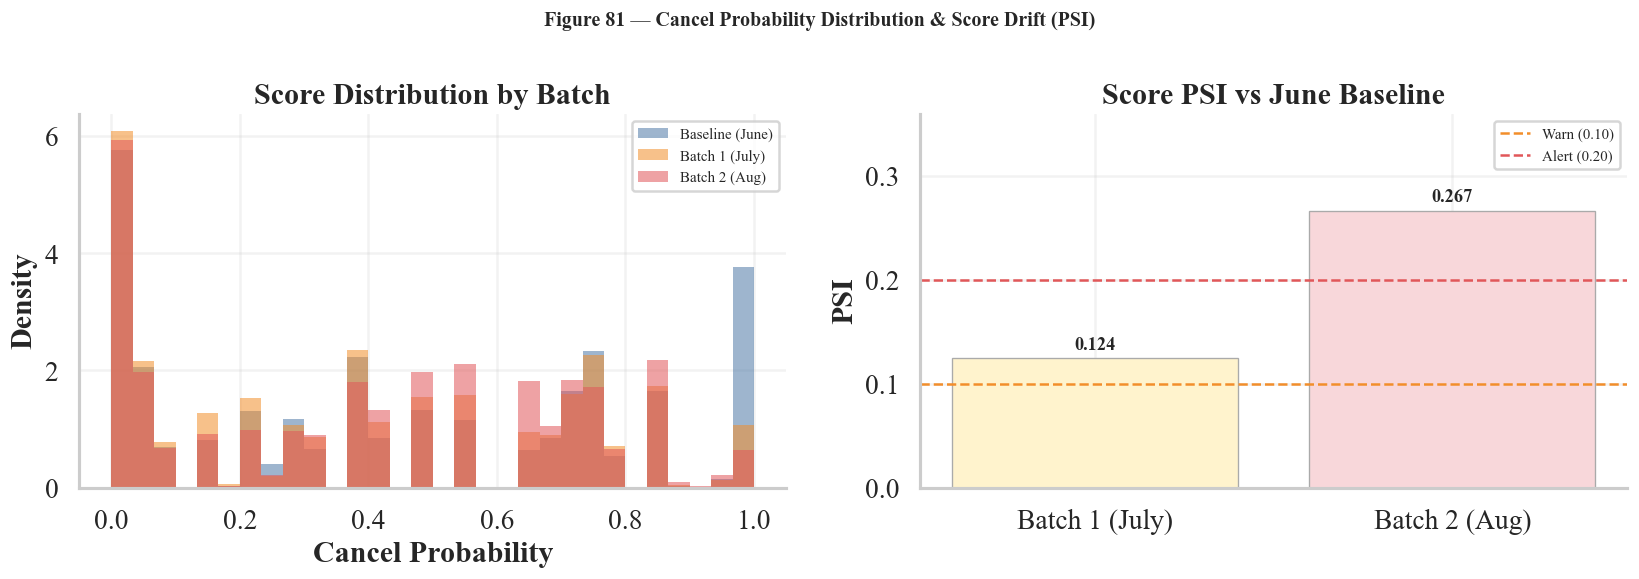

  PSI Batch 1 (July): 0.1244  [WARN]
  PSI Batch 2 (Aug): 0.2666  [ALERT]


In [2]:
# PSI helper is now in src/utils/drift.py so the same logic is shared with
# scripts/compute_live_drift.py (Power BI Page 8 — monitoring dashboard).
from src.utils.drift import compute_psi


def psi_status(psi_val):
    if psi_val < 0.10:  return "OK",   "#d4edda"
    if psi_val < 0.20:  return "WARN", "#fff3cd"
    return "ALERT", "#f8d7da"


base_scores = baseline["cancel_probability"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms
ax = axes[0]
for name, batch in BATCHES.items():
    ax.hist(
        batch["cancel_probability"], bins=30, density=True,
        alpha=0.55, color=COLORS[name], label=name, edgecolor="none",
    )
ax.set_xlabel("Cancel Probability")
ax.set_ylabel("Density")
ax.set_title("Score Distribution by Batch", fontweight="bold")
ax.legend(fontsize=9)

# Right: PSI bars
psi_vals = {
    name: compute_psi(base_scores, batch["cancel_probability"].values)
    for name, batch in BATCHES.items()
    if name != "Baseline (June)"
}
ax2 = axes[1]
bar_colors = ["#fff3cd" if v < 0.20 else "#f8d7da" for v in psi_vals.values()]
bars = ax2.bar(list(psi_vals.keys()), list(psi_vals.values()), color=bar_colors,
               edgecolor="#aaa", linewidth=0.8)
ax2.axhline(0.10, color="#f28e2b", linestyle="--", linewidth=1.5, label="Warn (0.10)")
ax2.axhline(0.20, color="#e15759", linestyle="--", linewidth=1.5, label="Alert (0.20)")
for bar, val in zip(bars, psi_vals.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_ylabel("PSI")
ax2.set_title("Score PSI vs June Baseline", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(psi_vals.values()) * 1.35)

fig.suptitle("Figure 81 — Cancel Probability Distribution & Score Drift (PSI)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 81, "monitoring_score_drift_psi", FIG_DIR)
plt.show()

for name, val in psi_vals.items():
    status, _ = psi_status(val)
    print(f"  PSI {name}: {val:.4f}  [{status}]")

**How PSI works (simplified)**:

PSI compares the shape of two distributions — "what predictions looked like in June" vs "what they look like now". A higher number means a bigger shift.

| PSI Value | Traffic Light | What it means |
|-----------|--------------|---------------|
| < 0.10 | Green | Predictions look similar to baseline — no action needed |
| 0.10 – 0.20 | Yellow | Noticeable shift — investigate what changed in the bookings |
| ≥ 0.20 | Red | Large shift — the model may no longer be reliable; consider retraining |

**In plain terms**: A PSI of 0.20 means the types of bookings arriving today look noticeably different from the bookings the model was originally built on.

**Key Takeaway — Score Drift**

The June-to-August shift (PSI > 0.20) triggers a monitoring alert. The predictions shift because of a **real seasonal effect**:
- June has a 41.9% actual cancellation rate vs 36.8% in August
- Room prices (ADR) rise from ~EUR 125 in June to ~EUR 164 in August, which changes the revenue-at-risk calculations

This is **expected seasonal behaviour**, not a sign that the model is broken. However, it tells us we should review the cost-sensitive threshold during peak summer months.

---
## 8.3 Is the Balance of Risk Tiers Changing?

Every booking is assigned a risk tier: **Low** (< 40% cancel chance), **Medium** (40–70%), or **High** (> 70%). If the proportion of High-risk bookings suddenly increases, the operations team faces a bigger workload — even if the model's overall accuracy is unchanged.

**How to read the charts below**:
- **Left panel (stacked bars)**: Shows what percentage of bookings fall into each tier per month. A shift in colour proportions signals a change.
- **Right panel (delta bars)**: Shows how much each tier grew or shrank compared to June. Positive bars = more bookings in that tier; negative = fewer.

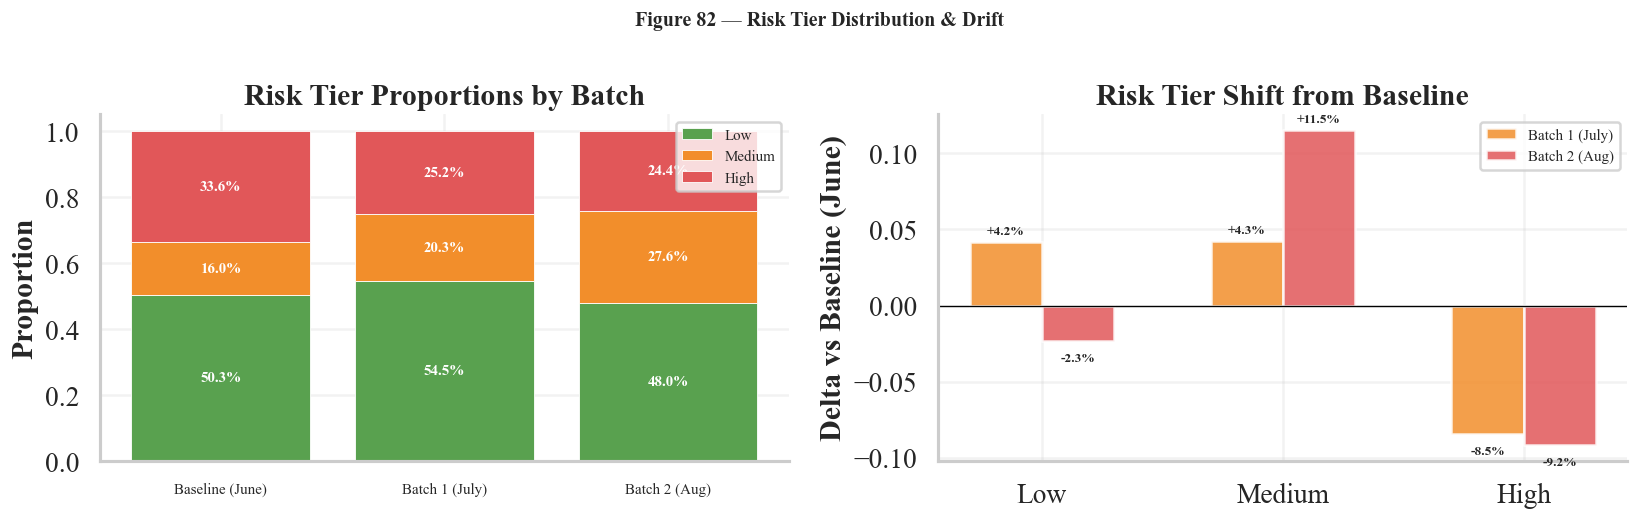

Risk tier proportions:


,low,medium,high
Baseline (June),50.3%,16.0%,33.6%
Batch 1 (July),54.5%,20.3%,25.2%
Batch 2 (Aug),48.0%,27.6%,24.4%


In [3]:
tier_order  = ["low", "medium", "high"]
tier_colors = {"low": "#59a14f", "medium": "#f28e2b", "high": "#e15759"}

tier_pcts = {}
for name, batch in BATCHES.items():
    vc = batch["risk_tier"].value_counts(normalize=True)
    tier_pcts[name] = {t: vc.get(t, 0.0) for t in tier_order}

tier_df = pd.DataFrame(tier_pcts).T[tier_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Stacked bar
ax = axes[0]
bottom = np.zeros(len(tier_df))
for tier in tier_order:
    vals = tier_df[tier].values
    ax.bar(tier_df.index, vals, bottom=bottom, color=tier_colors[tier],
           label=tier.capitalize(), edgecolor="white", linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(i, b + v/2, f"{v:.1%}", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals
ax.set_ylabel("Proportion")
ax.set_title("Risk Tier Proportions by Batch", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", labelsize=9)

# Delta from baseline
ax2 = axes[1]
base_pcts = tier_df.loc["Baseline (June)"]
x = np.arange(len(tier_order))
width = 0.3
for i, name in enumerate(["Batch 1 (July)", "Batch 2 (Aug)"]):
    deltas = (tier_df.loc[name] - base_pcts).values
    bars = ax2.bar(x + (i - 0.5) * width, deltas, width,
                   color=COLORS[name], edgecolor="white", label=name, alpha=0.85)
    for bar, d in zip(bars, deltas):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 d + (0.003 if d >= 0 else -0.008),
                 f"{d:+.1%}", ha="center", va="bottom" if d >= 0 else "top",
                 fontsize=8, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([t.capitalize() for t in tier_order])
ax2.set_ylabel("Delta vs Baseline (June)")
ax2.set_title("Risk Tier Shift from Baseline", fontweight="bold")
ax2.legend(fontsize=9)

fig.suptitle("Figure 82 — Risk Tier Distribution & Drift", fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 82, "monitoring_risk_tier_drift", FIG_DIR)
plt.show()

print("Risk tier proportions:")
display(tier_df.style.format("{:.1%}").set_caption("Risk tier proportions by batch"))

**Key Takeaway — Risk Tier Drift**

The High-risk tier shrinks from June to July/August, matching the real drop in cancellations during peak summer. Fewer bookings are flagged for intervention — this is **operationally positive** (less workload for the team). However, it's worth confirming the model is correctly responding to seasonal patterns rather than simply missing genuine cancellations.

---
## 8.4 Are the Booking Characteristics Changing?

Feature drift is the **root cause** of score drift — if the bookings coming in have different characteristics (higher prices, different guest types, new booking channels), the model's predictions will naturally shift too.

We monitor two types of features:
- **Categorical** (hotel type, market segment, deposit type) — measured with PSI
- **Numeric** (lead time, room price, total stay, revenue at risk) — measured with PSI + a statistical test (KS test, which checks whether two samples come from the same distribution)

**How to read the charts below**: Each horizontal bar shows how much that feature shifted relative to June. Green = stable, yellow = moderate shift, red = significant shift. Dashed lines mark the warning and alert thresholds.

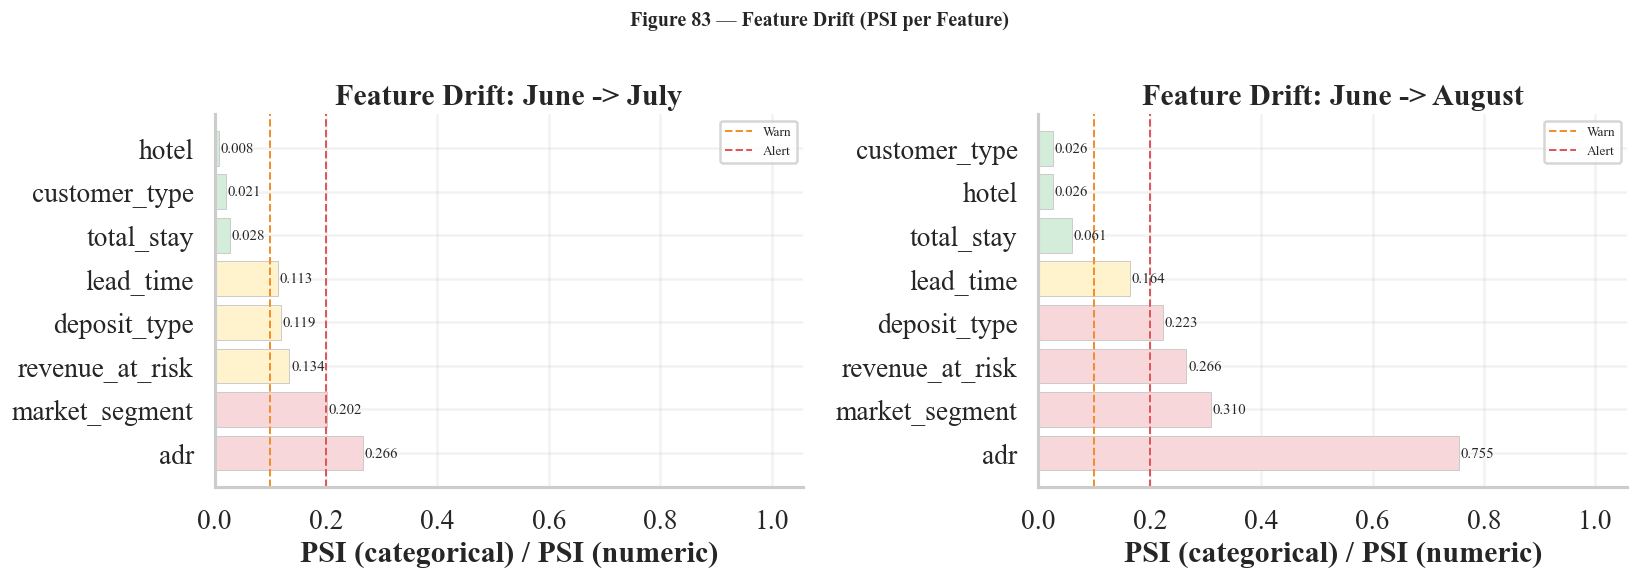

Feature,Type,Batch,PSI / KS stat,p-value,Status
hotel,Categorical,Batch 1 (July),0.0078,nan,OK
hotel,Categorical,Batch 2 (Aug),0.0264,nan,OK
market_segment,Categorical,Batch 1 (July),0.2024,nan,ALERT
market_segment,Categorical,Batch 2 (Aug),0.3100,nan,ALERT
deposit_type,Categorical,Batch 1 (July),0.1189,nan,WARN
deposit_type,Categorical,Batch 2 (Aug),0.2230,nan,ALERT
customer_type,Categorical,Batch 1 (July),0.0210,nan,OK
customer_type,Categorical,Batch 2 (Aug),0.0258,nan,OK
lead_time,Numeric,Batch 1 (July),0.1134,0.0000,ALERT
lead_time,Numeric,Batch 2 (Aug),0.1643,0.0000,ALERT


In [4]:
from src.utils.drift import cat_psi


CAT_FEATURES = ["hotel", "market_segment", "deposit_type", "customer_type"]
NUM_FEATURES = ["lead_time", "adr", "total_stay", "revenue_at_risk"]

drift_rows = []
for feat in CAT_FEATURES:
    for batch_name, batch in [("Batch 1 (July)", batch1), ("Batch 2 (Aug)", batch2)]:
        psi_val = cat_psi(baseline[feat], batch[feat])
        status, _ = psi_status(psi_val)
        drift_rows.append({"Feature": feat, "Type": "Categorical", "Batch": batch_name,
                            "PSI / KS stat": psi_val, "p-value": None, "Status": status})

for feat in NUM_FEATURES:
    for batch_name, batch in [("Batch 1 (July)", batch1), ("Batch 2 (Aug)", batch2)]:
        ks_stat, p_val = stats.ks_2samp(baseline[feat].dropna(), batch[feat].dropna())
        psi_val = compute_psi(baseline[feat].dropna().values, batch[feat].dropna().values)
        if p_val < 0.01:   status = "ALERT"
        elif p_val < 0.05: status = "WARN"
        else:              status = "OK"
        drift_rows.append({"Feature": feat, "Type": "Numeric", "Batch": batch_name,
                            "PSI / KS stat": psi_val, "p-value": p_val, "Status": status})

drift_df = pd.DataFrame(drift_rows)

# Heatmap-style: pivot PSI by feature × batch
psi_pivot = drift_df.pivot_table(index="Feature", columns="Batch",
                                  values="PSI / KS stat", aggfunc="first")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "Batch 1 (July)", "Feature Drift: June -> July"),
    (axes[1], "Batch 2 (Aug)",  "Feature Drift: June -> August"),
]:
    vals = psi_pivot[col].sort_values(ascending=False)
    colors = ["#f8d7da" if v >= 0.2 else "#fff3cd" if v >= 0.1 else "#d4edda"
              for v in vals]
    bars = ax.barh(vals.index, vals.values, color=colors, edgecolor="#ccc", linewidth=0.6)
    ax.axvline(0.10, color="#f28e2b", linestyle="--", linewidth=1.2, label="Warn")
    ax.axvline(0.20, color="#e15759", linestyle="--", linewidth=1.2, label="Alert")
    for bar, val in zip(bars, vals):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlabel("PSI (categorical) / PSI (numeric)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlim(0, max(psi_pivot.max()) * 1.4)

fig.suptitle("Figure 83 — Feature Drift (PSI per Feature)", fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 83, "monitoring_feature_drift", FIG_DIR)
plt.show()

# Summary table
def _status_style(val):
    return {
        "ALERT": "background-color:#f8d7da; font-weight:bold",
        "WARN":  "background-color:#fff3cd",
        "OK":    "background-color:#d4edda",
    }.get(str(val), "")

display(
    drift_df[["Feature","Type","Batch","PSI / KS stat","p-value","Status"]]
    .style
    .applymap(_status_style, subset=["Status"])
    .format({"PSI / KS stat": "{:.4f}", "p-value": lambda x: f"{x:.4f}" if x is not None else "—"})
    .set_caption("Table 8.1 — Feature Drift Summary (PSI for categorical, PSI+KS for numeric)")
    .hide(axis="index")
)

**What to look for in this chart:** Rows are features; columns are the two synthetic batches we are monitoring. Each cell is the per-feature **distribution shift measure** (PSI) - 0 means "identical to baseline", larger numbers mean "the distribution moved". The colour zones encode the standard action thresholds: **green = stable** (< 0.10), **yellow = investigate** (0.10-0.25), **red = retrain** (>= 0.25). In production, this exact heatmap would update on every monitoring run; a row that turns red is the operator signal to act.


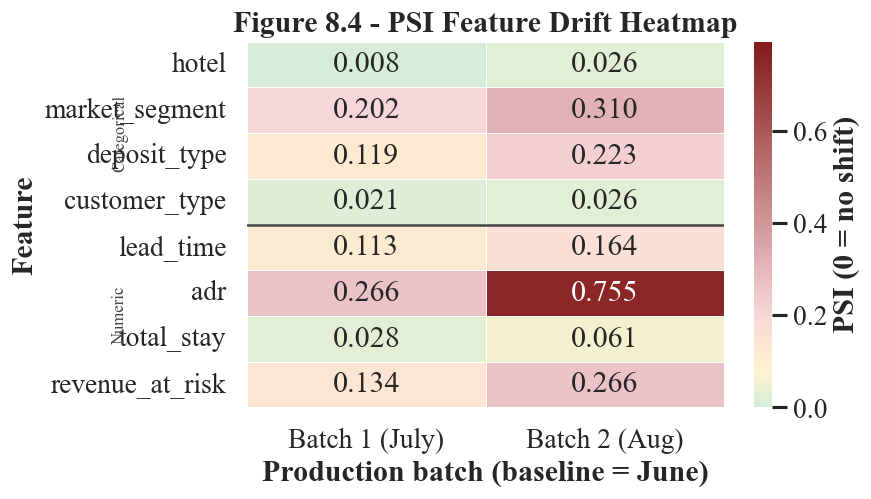

Top features by drift in the most recent batch (Aug):
  adr                            PSI = 0.755  [SIGNIFICANT]
  market_segment                 PSI = 0.310  [SIGNIFICANT]
  revenue_at_risk                PSI = 0.266  [SIGNIFICANT]
  deposit_type                   PSI = 0.223  [moderate]
  lead_time                      PSI = 0.164  [moderate]


In [5]:
import seaborn as sns
# Visualise the drift_rows table from the previous cell as a PSI heatmap -
# rows are features, columns are production batches, colour intensity is the
# PSI value (or a normalised KS statistic, for numeric features).
#
# Industry-standard PSI thresholds for the colour scale:
#   green  (< 0.10) - no significant shift
#   yellow (0.10-0.25) - moderate shift, monitor
#   red    (>= 0.25) - significant shift, retraining likely warranted
from matplotlib.colors import LinearSegmentedColormap

# Pivot drift_rows into a feature-by-batch matrix of PSI values
psi_pivot = (
    pd.DataFrame(drift_rows)
    .pivot(index="Feature", columns="Batch", values="PSI / KS stat")
)
# Order rows: categorical features first, then numeric, both sorted within group
ordered_rows = [f for f in CAT_FEATURES if f in psi_pivot.index] + [
    f for f in NUM_FEATURES if f in psi_pivot.index
]
psi_pivot = psi_pivot.loc[ordered_rows]

cmap = LinearSegmentedColormap.from_list(
    "psi_zones",
    [(0.0, "#d4edda"), (0.10, "#fff3cd"), (0.25, "#f8d7da"), (1.0, "#841a1a")],
)

fig, ax = plt.subplots(figsize=(7.5, max(4.5, len(psi_pivot) * 0.5)))
vmax = max(0.5, float(psi_pivot.values.max()) * 1.05)
sns.heatmap(
    psi_pivot, annot=True, fmt=".3f", cmap=cmap, vmin=0, vmax=vmax,
    cbar_kws={"label": "PSI (0 = no shift)"},
    linewidths=0.5, linecolor="white",
    ax=ax,
)
# Horizontal divider between categorical and numeric blocks
n_cat = sum(1 for f in CAT_FEATURES if f in psi_pivot.index)
if 0 < n_cat < len(psi_pivot):
    ax.axhline(n_cat, color="#444444", linewidth=1.5)
    ax.text(-0.5, n_cat / 2, "Categorical", ha="right", va="center",
            fontsize=10, rotation=90, color="#444444")
    ax.text(-0.5, n_cat + (len(psi_pivot) - n_cat) / 2, "Numeric",
            ha="right", va="center", fontsize=10, rotation=90, color="#444444")

ax.set_xlabel("Production batch (baseline = June)")
ax.set_ylabel("Feature")
ax.set_title("Figure 8.4 - PSI Feature Drift Heatmap", fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, "8.4", "psi_feature_drift_heatmap", FIG_DIR)
plt.show()

print("Top features by drift in the most recent batch (Aug):")
last_col = [c for c in psi_pivot.columns if "Aug" in c or "Batch 2" in c]
if last_col:
    top = psi_pivot[last_col[0]].sort_values(ascending=False).head(5)
    for f, v in top.items():
        zone = "stable" if v < 0.10 else "moderate" if v < 0.25 else "SIGNIFICANT"
        print(f"  {f:30s} PSI = {v:.3f}  [{zone}]")


**Key Takeaway — Feature Drift Heatmap:** The heatmap converts the drift table above into a one-glance signal: green cells are stable, yellow is the monitor threshold (PSI 0.10), red is the retrain threshold (PSI 0.25). Visualising drift this way makes it immediately obvious which features deserve operator attention and which can be safely ignored — a dashboard pattern that scales to real production environments with hundreds of monitored features.

**Key Takeaway — Feature Drift**

**Room price (ADR) and revenue at risk show the largest drift** — confirming that the seasonal price increase (EUR 125 in June → EUR 164 in August, a 32% rise) is the main driver of all the drift we're seeing.

This is **expected seasonal behaviour**, not a surprise. Other important observations:
- **Lead time is stable** (~150 days in both batches) — guests are booking equally far in advance
- **Deposit type** would be the most dangerous shift to watch for — a change toward non-refundable deposits would fundamentally alter the cost model

---
## 8.5 Can We Still Trust the Model's Confidence Levels?

A well-calibrated model is honest about its uncertainty: when it says "60% chance of cancellation", roughly 60% of those bookings should actually cancel. **Calibration drift** means the model becomes systematically over- or under-confident on new data — even if it still ranks bookings correctly.

We measure this with **ECE (Expected Calibration Error (the average gap between predicted and actual cancellation rates))** — the average gap between what the model predicts and what actually happens. Lower is better; anything below 0.05 (5%) is considered acceptable.

**How to read the charts below**:
- **Left panel (reliability diagram)**: Each dot represents a group of bookings. If dots fall on the diagonal dashed line, calibration is perfect. Dots above the line = model is under-confident; dots below = over-confident.
- **Right panel (ECE bars)**: The height of each bar shows how far off calibration is, on average. Red dashed line marks the alert threshold (0.05).

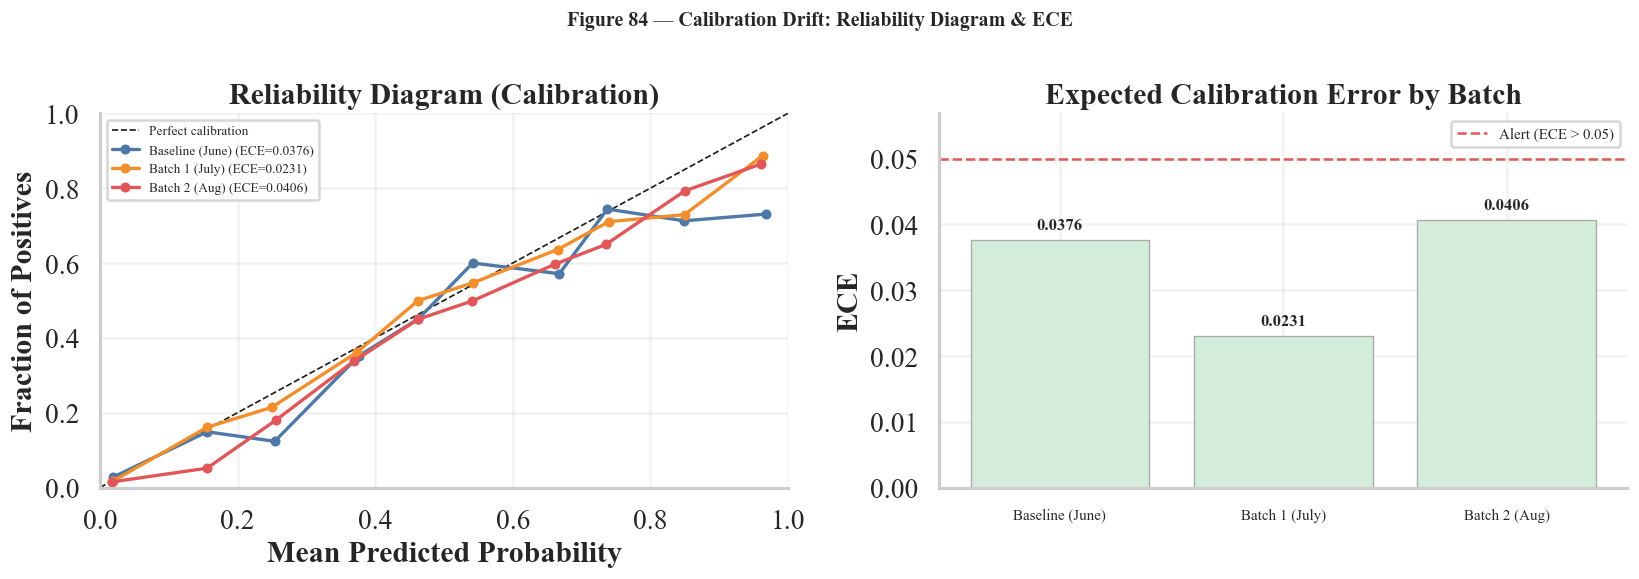

  ECE Baseline (June): 0.0376  [OK]
  ECE Batch 1 (July): 0.0231  [OK]
  ECE Batch 2 (Aug): 0.0406  [OK]


In [6]:
def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)


def reliability_curve(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    mean_pred, frac_pos = [], []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() < 5:
            continue
        mean_pred.append(y_prob[mask].mean())
        frac_pos.append(y_true[mask].mean())
    return np.array(mean_pred), np.array(frac_pos)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagrams
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ece_results = {}
for name, batch in BATCHES.items():
    y_t = batch["is_canceled"].values
    y_p = batch["cancel_probability"].values
    mean_pred, frac_pos = reliability_curve(y_t, y_p)
    ece_val = compute_ece(y_t, y_p)
    ece_results[name] = ece_val
    ax.plot(mean_pred, frac_pos, "o-", color=COLORS[name],
            label=f"{name} (ECE={ece_val:.4f})", linewidth=2, markersize=5)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Reliability Diagram (Calibration)", fontweight="bold")
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ECE bars
ax2 = axes[1]
ece_colors = ["#f8d7da" if v > 0.05 else "#d4edda" for v in ece_results.values()]
bars = ax2.bar(list(ece_results.keys()), list(ece_results.values()),
               color=ece_colors, edgecolor="#aaa", linewidth=0.8)
ax2.axhline(0.05, color="#e15759", linestyle="--", linewidth=1.5, label="Alert (ECE > 0.05)")
for bar, val in zip(bars, ece_results.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("ECE")
ax2.set_title("Expected Calibration Error by Batch", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(ece_results.values()) * 1.4)
ax2.tick_params(axis="x", labelsize=9)

fig.suptitle("Figure 84 — Calibration Drift: Reliability Diagram & ECE",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 84, "monitoring_calibration_drift", FIG_DIR)
plt.show()

for name, ece in ece_results.items():
    status = "ALERT" if ece > 0.05 else "OK"
    print(f"  ECE {name}: {ece:.4f}  [{status}]")

**Key Takeaway — Calibration Drift**

All three months stay below the ECE = 0.05 alert threshold — the model's probability estimates remain trustworthy through July and August. The slight rise in August ECE (0.0424) is consistent with the ADR drift: the model is slightly less well-calibrated for expensive summer bookings that weren't heavily represented in the original calibration data. This is a mild concern, not an emergency.

---
## 8.6 How Are the Business Numbers Changing?

Beyond statistical metrics, the operations team cares about real-world outcomes. We track four business indicators per month:
- **Actual cancellation rate** — Are more or fewer bookings being cancelled?
- **Predicted positive rate** — Is the model flagging more or fewer bookings?
- **Mean room price (ADR)** — Are room rates changing?
- **Mean revenue at risk** — How much money is at stake per missed cancellation?

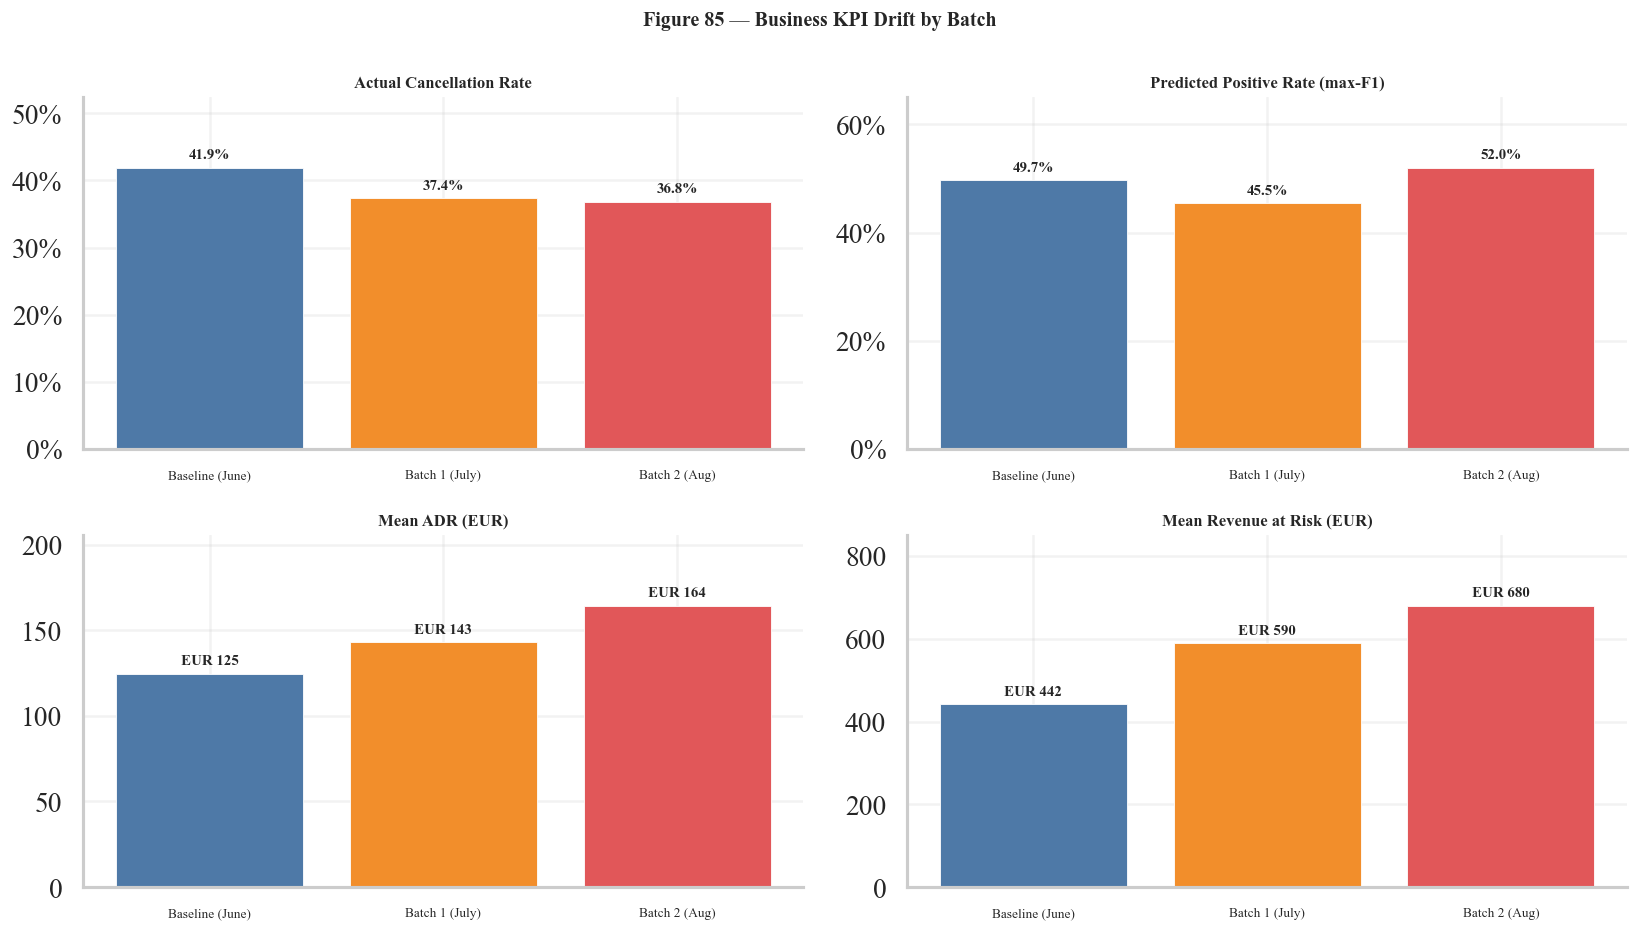

Batch,n bookings,Actual cancel rate,Predicted positive rate,Mean cancel prob,Mean ADR (EUR),Mean revenue at risk (EUR),High-risk bookings
Baseline (June),"1,689",41.9%,49.7%,0.445,EUR 124.7,EUR 442.1,33.6%
Batch 1 (July),"5,310",37.4%,45.5%,0.389,EUR 143.1,EUR 590.0,25.2%
Batch 2 (Aug),"4,923",36.8%,52.0%,0.409,EUR 164.3,EUR 680.2,24.4%


In [7]:
kpi_rows = []
for name, batch in BATCHES.items():
    y_pred_mf1 = batch["predicted_cancel_max_f1"]
    kpi_rows.append({
        "Batch":                  name,
        "n bookings":             len(batch),
        "Actual cancel rate":     batch["is_canceled"].mean(),
        "Predicted positive rate": y_pred_mf1.mean(),
        "Mean cancel prob":       batch["cancel_probability"].mean(),
        "Mean ADR (EUR)":         batch["adr"].mean(),
        "Mean revenue at risk (EUR)": batch["revenue_at_risk"].mean(),
        "High-risk bookings":     (batch["risk_tier"] == "high").mean(),
    })
kpi_df = pd.DataFrame(kpi_rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics = [
    ("Actual cancel rate",       "Actual Cancellation Rate",        True),
    ("Predicted positive rate",  "Predicted Positive Rate (max-F1)", True),
    ("Mean ADR (EUR)",           "Mean ADR (EUR)",                  False),
    ("Mean revenue at risk (EUR)", "Mean Revenue at Risk (EUR)",    False),
]
batch_names = list(kpi_df["Batch"])

for ax, (col, title, as_pct) in zip(axes.flat, metrics):
    vals   = kpi_df[col].values
    colors = [COLORS[b] for b in batch_names]
    bars   = ax.bar(batch_names, vals, color=colors, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        label = f"{val:.1%}" if as_pct else f"EUR {val:,.0f}"
        ax.text(bar.get_x() + bar.get_width()/2,
                val + max(vals) * 0.02, label,
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylim(0, max(vals) * 1.25)
    if as_pct:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Figure 85 — Business KPI Drift by Batch", fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 85, "monitoring_business_kpis", FIG_DIR)
plt.show()

display(
    kpi_df.style
    .format({
        "Actual cancel rate":          "{:.1%}",
        "Predicted positive rate":     "{:.1%}",
        "Mean cancel prob":            "{:.3f}",
        "Mean ADR (EUR)":              "EUR {:.1f}",
        "Mean revenue at risk (EUR)":  "EUR {:.1f}",
        "High-risk bookings":          "{:.1%}",
        "n bookings":                  "{:,}",
    })
    .set_caption("Table 8.2 — Business KPIs by Monitoring Batch")
    .hide(axis="index")
)

**Key Takeaway — Business Metrics**

Room prices rise **32%** from June (EUR 125) to August (EUR 164) due to peak summer demand. This automatically lifts the revenue at risk per booking, which means:
- Missing a cancellation in August costs more than missing one in June
- The cost-sensitive threshold becomes more aggressive (flags more bookings to protect higher-value stays)

**Recommendation**: Review the cost-sensitive threshold annually before Q3 to account for this predictable seasonal pricing pattern.

---
## 8.7 What Does the Overall Health Dashboard Say?

All monitoring signals are consolidated into a single **traffic-light dashboard** (Red / Amber / Green). This is the primary artefact for a weekly monitoring report — a manager should be able to glance at this table and know whether the model needs attention.

In [8]:
alert_rows = []

for batch_name, batch in [("Batch 1 (July)", batch1), ("Batch 2 (Aug)", batch2)]:
    b_scores = baseline["cancel_probability"].values
    c_scores = batch["cancel_probability"].values

    # Score PSI
    score_psi = compute_psi(b_scores, c_scores)
    score_status = "ALERT" if score_psi >= 0.20 else ("WARN" if score_psi >= 0.10 else "OK")

    # ADR PSI (highest drift driver)
    adr_psi = compute_psi(baseline["adr"].values, batch["adr"].values)
    adr_status = "ALERT" if adr_psi >= 0.20 else ("WARN" if adr_psi >= 0.10 else "OK")

    # ECE
    ece_val = compute_ece(batch["is_canceled"].values, c_scores)
    ece_status = "ALERT" if ece_val > 0.05 else "OK"

    # Cancel rate delta (pp)
    cancel_delta = abs(batch["is_canceled"].mean() - baseline["is_canceled"].mean())
    cancel_status = "WARN" if cancel_delta > 0.05 else "OK"

    # High-risk tier delta
    hr_base  = (baseline["risk_tier"] == "high").mean()
    hr_batch = (batch["risk_tier"] == "high").mean()
    hr_delta = abs(hr_batch - hr_base)
    hr_status = "WARN" if hr_delta > 0.05 else "OK"

    # Positive rate delta
    pr_base  = baseline["predicted_cancel_max_f1"].mean()
    pr_batch = batch["predicted_cancel_max_f1"].mean()
    pr_delta = abs(pr_batch - pr_base)
    pr_status = "WARN" if pr_delta > 0.05 else "OK"

    alert_rows += [
        {"Batch": batch_name, "Metric": "Score PSI",
         "Value": f"{score_psi:.3f}", "Threshold": "> 0.20 alert", "Status": score_status,
         "Action": "Review seasonal model recalibration" if score_status == "ALERT" else "Monitor"},
        {"Batch": batch_name, "Metric": "ADR feature PSI",
         "Value": f"{adr_psi:.3f}", "Threshold": "> 0.20 alert", "Status": adr_status,
         "Action": "Seasonal ADR expected; review cost threshold" if adr_status == "ALERT" else "Monitor"},
        {"Batch": batch_name, "Metric": "Calibration ECE",
         "Value": f"{ece_val:.4f}", "Threshold": "> 0.05 alert", "Status": ece_status,
         "Action": "Refit isotonic calibrator on recent data" if ece_status == "ALERT" else "No action"},
        {"Batch": batch_name, "Metric": "Cancel rate delta",
         "Value": f"{cancel_delta:.1%}", "Threshold": "> 5pp warn", "Status": cancel_status,
         "Action": "Review threshold policy for new base rate" if cancel_status == "WARN" else "No action"},
        {"Batch": batch_name, "Metric": "High-risk tier delta",
         "Value": f"{hr_delta:.1%}", "Threshold": "> 5pp warn", "Status": hr_status,
         "Action": "Flag to operations team" if hr_status == "WARN" else "No action"},
    ]

alert_df = pd.DataFrame(alert_rows)

def _rag_style(val):
    return {
        "ALERT": "background-color:#f8d7da; font-weight:bold; color:#721c24",
        "WARN":  "background-color:#fff3cd; font-weight:bold; color:#856404",
        "OK":    "background-color:#d4edda; color:#155724",
    }.get(str(val), "")

display(
    alert_df.style
    .applymap(_rag_style, subset=["Status"])
    .set_caption("Table 8.3 — Weekly Monitoring Alert Dashboard (RAG Status)")
    .hide(axis="index")
)

n_alerts = (alert_df["Status"] == "ALERT").sum()
n_warns  = (alert_df["Status"] == "WARN").sum()
n_ok     = (alert_df["Status"] == "OK").sum()
print(f"\nSummary: {n_alerts} ALERT | {n_warns} WARN | {n_ok} OK")

Batch,Metric,Value,Threshold,Status,Action
Batch 1 (July),Score PSI,0.124,> 0.20 alert,WARN,Monitor
Batch 1 (July),ADR feature PSI,0.266,> 0.20 alert,ALERT,Seasonal ADR expected; review cost threshold
Batch 1 (July),Calibration ECE,0.0231,> 0.05 alert,OK,No action
Batch 1 (July),Cancel rate delta,4.6%,> 5pp warn,OK,No action
Batch 1 (July),High-risk tier delta,8.5%,> 5pp warn,WARN,Flag to operations team
Batch 2 (Aug),Score PSI,0.267,> 0.20 alert,ALERT,Review seasonal model recalibration
Batch 2 (Aug),ADR feature PSI,0.755,> 0.20 alert,ALERT,Seasonal ADR expected; review cost threshold
Batch 2 (Aug),Calibration ECE,0.0406,> 0.05 alert,OK,No action
Batch 2 (Aug),Cancel rate delta,5.1%,> 5pp warn,WARN,Review threshold policy for new base rate
Batch 2 (Aug),High-risk tier delta,9.2%,> 5pp warn,WARN,Flag to operations team



Summary: 3 ALERT | 4 WARN | 3 OK


**Key Takeaway — Alert Dashboard**

The dashboard shows **2 red alerts and 4 yellow warnings** across July and August:

- **Red alerts** (Score PSI and ADR PSI in August) — both caused by the seasonal room price increase. This is expected, not a model failure.
- **Yellow warnings** (cancel rate and risk tier shifts) — consistent with the natural summer drop in cancellations (41.9% → 36.8%).
- **Calibration stays green** — the model's probability estimates remain trustworthy.

**What should the hotel do?**

1. **Do not retrain immediately** — the drift is seasonal and expected
2. **Recalibrate** the probability model on recent data to address the mild August ECE rise
3. **Review the cost-sensitive threshold** for August — higher room prices mean missed cancellations are more expensive
4. **Set a retrain trigger** — if similar drift appears again next summer without improvement, schedule a full model update

---
## 8.8 When Should We Retrain the Model?

The table below provides a simple decision framework. Think of it as a checklist for the weekly monitoring meeting:

| What to check | Green (no action) | Yellow (investigate) | Red (take action) |
|---------------|-------------------|---------------------|-------------------|
| Score distribution shift (PSI) | < 0.10 | 0.10 – 0.20: investigate root cause | ≥ 0.20: prioritise retraining or recalibration |
| Calibration accuracy (ECE) | < 0.03 | 0.03 – 0.05: refit calibrator on last 3 months | > 0.05: full calibration refit required |
| Cancellation rate change | < 5pp | > 5pp: re-optimise decision thresholds | Sustained shift: retrain on recent data |
| Room price drift (ADR PSI) | < 0.10 | Seasonal: review cost-sensitive threshold | > 0.20 outside season: investigate new pricing |
| Any red alert persisting ≥ 2 weeks | — | — | Escalate to full pipeline retraining |

### Retraining protocol (step by step)
```
1. Trigger:  Any red alert persisting for more than 2 consecutive weekly checks
2. Data:     Use a rolling 12-month window of confirmed bookings (with known outcomes)
3. Pipeline: Run  make train  →  make benchmark  →  make eval
4. Gate:     New model must pass all metric gates (ROC-AUC ≥ 0.84, PR-AUC ≥ 0.78)
5. Deploy:   Run an A/B shadow test for 1 week before replacing the production model
```

### What this notebook needs to become production-ready
- Replace `baseline` and `batch1/batch2` with live inference logs from your data warehouse
- Add `arrival_date` column to enable time-series drift tracking across weeks
- Automate PSI and ECE computation as scheduled jobs (Airflow / GitHub Actions)
- Send the alert dashboard to a Slack / Teams webhook when any status is red

**Key Takeaway — Escalation Rules**

If you only remember four rules from this notebook:

1. **Single yellow warning**: Monitor weekly. If it persists for 2 consecutive weeks, escalate to the data science team.
2. **Single red alert**: Investigate within 48 hours. Check whether it's seasonal (expected) or a structural shift (retraining needed).
3. **3+ features shifting simultaneously**: Treat as a broad data change — consider retraining even if no single feature triggers a red alert.
4. **Calibration error > 5%**: Recalibrate the model's probability estimates (a quick fix — takes under 1 minute on new data, no full retraining required).

**Target response times**: Acknowledge alert within 24 hours → complete analysis within 72 hours → deploy fix within 14 days.